# 3D Arena Sankeys

In [67]:
# imports

import pandas as pd
import plotly.graph_objects as go
import os
import matplotlib.pyplot as plt
! pip install -U kaleido

In [68]:
# MAKE CHANGES HERE

# Input files used for analysis
filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\combined_matrix_final_total_mp.csv'
filename_groups = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\cluster_groups_matlab.csv'

# Output directory for cluster usage change .csv files
output_dir = r'D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs'
os.makedirs(output_dir, exist_ok=True)

# Output directory for graphs. Use the path to .eps, .png will be automatically generated
eps_dir = r"D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps"

# Use any label for mouse
mouse_name = "2mp"  

Reading in Data

In [69]:
all_data = pd.read_csv(os.path.join(filename))
grouped_clusters = pd.read_csv(os.path.join(filename_groups))

Function Definitions

In [ ]:
# Pie Flow Chart
custom_colors_pies = [  
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
    "#1e90ff", "#ff1493", "#00ced1", "#ff69b4", "#7cfc00", "#ff6347", "#00ff7f", "#4682b4",
    "#da70d6", "#40e0d0", "#dc143c", "#00bfff", "#ff8c00", "#9932cc", "#8b0000", "#00fa9a",
    "#6495ed", "#ba55d3", "#f0e68c", "#ff00ff", "#00ffff", "#adff2f", "#ffa500", "#87ceeb",
    "#f08080", "#20b2aa", "#f5deb3", "#ffb6c1", "#2e8b57", "#ffdab9", "#b0e0e6", "#cd5c5c",
    "#dda0dd", "#fa8072", "#eee8aa", "#7fffd4", "#b22222", "#8fbc8f", "#ffdead", "#ff7f50",
    "#ffefd5", "#5f9ea0", "#ff69b4", "#bdb76b", "#8a2be2", "#ff1493", "#d2691e", "#bc8f8f",
    "#8b4513", "#00ced1", "#b0c4de", "#ffe4e1", "#2f4f4f", "#696969", "#d2b48c", "#fafad2"
]

week_numbers = sorted(all_data['Week_Number'].dropna().unique())

def create_sankey_and_pies(data, week_number, eps_dir="", mouse_name=""):
    data = data.copy()
    data['Next_Cluster'] = data['Cluster'].shift(-1)
    data['Next_Week_Number'] = data['Week_Number'].shift(-1)
    data = data[data['Week_Number'] == data['Next_Week_Number']]

    transition_counts = data.groupby(['Cluster', 'Next_Cluster']).size().unstack(fill_value=0)
    transition_probabilities = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    all_clusters = sorted(data['Cluster'].dropna().astype(int).unique())
    outgoing_counts = {f"Cluster {i}": 0 for i in all_clusters}
    incoming_counts = {f"Cluster {i}": 0 for i in all_clusters}

    for col in transition_probabilities.columns:
        for row in transition_probabilities.index:
            prob = transition_probabilities.at[row, col]
            if prob > 0:
                src = f"Cluster {int(row)}"
                tgt = f"Cluster {int(col)}"
                if src in outgoing_counts:
                    outgoing_counts[src] += 1
                if tgt in incoming_counts:
                    incoming_counts[tgt] += 1

    print(f"\n--- Incoming and Outgoing Flow Counts for Week {week_number} ---")


    def plot_pie_chart(counts, title, save_path=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        total = sum(sizes)

        display_labels = [
            label.replace("Cluster ", "") if (value / total * 100) >= 1 else ""
            for label, value in zip(labels, sizes)
        ]

        pie_colors = [custom_colors_pies[int(label.split()[1]) % len(custom_colors_pies)] for label in labels]

        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=display_labels,
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')
        
        if save_path is not None:
            eps_dir = os.path.dirname(save_path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(save_path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")
        plt.show()

    incoming_chart_counts = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart_counts = {k: v for k, v in outgoing_counts.items() if v > 0}

    incoming_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming.eps"
    )
    outgoing_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing.eps"
    )

    plot_pie_chart(incoming_chart_counts, f"Incoming Flows - Week {week_number}", save_path=incoming_path)
    plot_pie_chart(outgoing_chart_counts, f"Outgoing Flows - Week {week_number}", save_path=outgoing_path)


In [71]:
# Sankeys Grouped
custom_colors_sankey = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32"
]

group_list = sorted(grouped_clusters['Group'].dropna().unique())
color_map = {int(group): custom_colors_sankey[i % len(custom_colors_sankey)] for i, group in enumerate(group_list)}

def map_grouped_clusters(df):
    return df.merge(grouped_clusters[['Cluster', 'Group']], left_on='Cluster', right_on='Cluster', how='left')

def create_grouped_sankey_plot(data, week_number, save_path=None, mouse_name=''):
    data = map_grouped_clusters(data)
    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    unique_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    group_labels = [f"Group {g}" for g in unique_groups]
    label_indices = {f"Group {g}": i for i, g in enumerate(unique_groups)}
    n = len(unique_groups)

    transition_counts = data.groupby(['Group', 'Next_Group']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    source, target, values, colors = [], [], [], []

    for src in transition_probs.index:
        for tgt in transition_probs.columns:
            prob = transition_probs.at[src, tgt]
            if prob > 0:
                src_label = f"Group {src}"
                tgt_label = f"Group {tgt}"
                source.append(label_indices[src_label])
                target.append(label_indices[tgt_label] + n)
                values.append(prob)
                colors.append(color_map[src])

    scale = 0.6 
    offset = (1 - scale) / 2 
    y_values = [offset + scale * (i / (n - 1)) for i in range(n)] if n > 1 else [0.5]
    y_positions = y_values * 2
    x_positions = [0.1] * n + [0.9] * n

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=0.5),
            label=group_labels * 2,
            color="lightgray",
            x=x_positions,
            y=y_positions
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=colors
        )
    ))

    fig.update_layout(
        title_text=f"Grouped Cluster Transitions in Week {week_number}",
        font_size=12,
        height=1000,
        width=1000,
        margin=dict(l=10, r=100, t=50, b=50) 
    )

    if save_path is not None:
        eps_dir = save_path
        os.makedirs(eps_dir, exist_ok=True)
        base_filename = f"sankey_{mouse_name}_week{week_number}"

        svg_path = os.path.join(eps_dir, base_filename + ".svg")
        fig.write_image(svg_path)
        print(f"SVG saved to: {svg_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, "png")
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + ".png")
        fig.write_image(png_path)
        print(f"PNG saved to: {png_path}")

    fig.show()

In [ ]:
# Pie Flow Chart Grouped

custom_colors_pies_grouped = [
    "#32cd32", "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
]

def create_group_pie_flows(data, week_number, eps_dir="", mouse_name=""):
    data = data.copy()

    cluster_to_group = dict(zip(grouped_clusters['Cluster'], grouped_clusters['Group']))
    data['Group'] = data['Cluster'].map(cluster_to_group)

    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    all_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    outgoing_counts = {f"Group {i}": 0 for i in all_groups}
    incoming_counts = {f"Group {i}": 0 for i in all_groups}

    for _, row in data.iterrows():
        src = f"Group {int(row['Group'])}"
        tgt = f"Group {int(row['Next_Group'])}"
        outgoing_counts[src] += 1
        incoming_counts[tgt] += 1


    print(f"--- Group Flow Counts for Week {week_number} ---")

    def plot_pie_chart(counts, title, save_path=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        pie_colors = [custom_colors_pies_grouped[int(label.split()[-1]) % len(custom_colors_pies_grouped)] for label in labels]
        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=[label.replace("Group ", "") for label in labels],
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')

        if save_path is not None:
            eps_dir = os.path.dirname(save_path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(save_path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")

        plt.show()

    incoming_chart = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart = {k: v for k, v in outgoing_counts.items() if v > 0}

    incoming_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming_grouped.eps"
    )
    outgoing_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing_grouped.eps"
    )

    plot_pie_chart(incoming_chart, f"Incoming Group Flows - Week {week_number}", save_path=incoming_path)
    plot_pie_chart(outgoing_chart, f"Outgoing Group Flows - Week {week_number}", save_path=outgoing_path)


Analysis


--- Incoming and Outgoing Flow Counts for Week 8 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week8_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week8_incoming.png


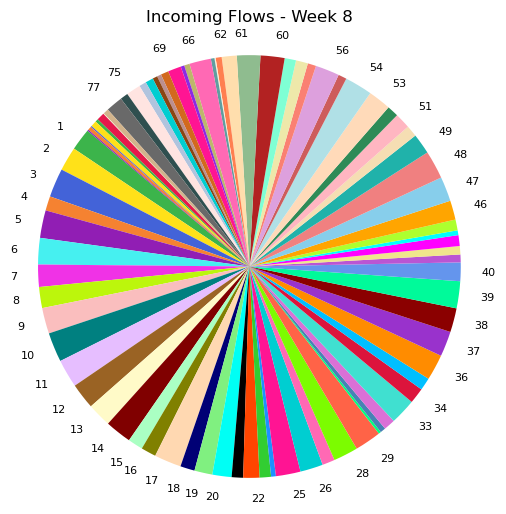

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week8_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week8_outgoing.png


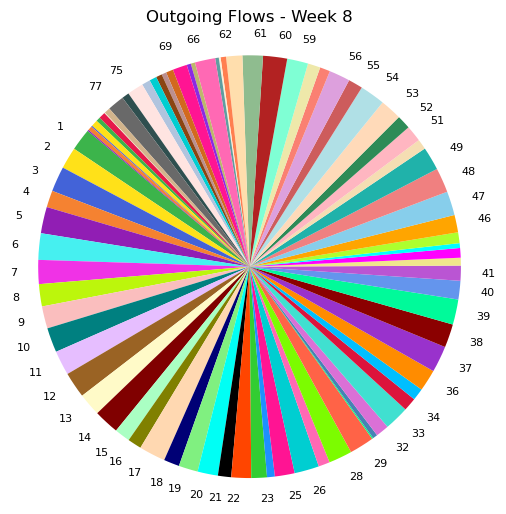


--- Incoming and Outgoing Flow Counts for Week 10 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week10_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week10_incoming.png


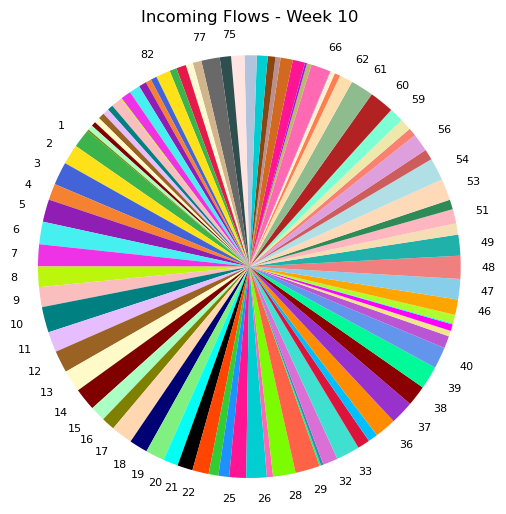

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week10_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week10_outgoing.png


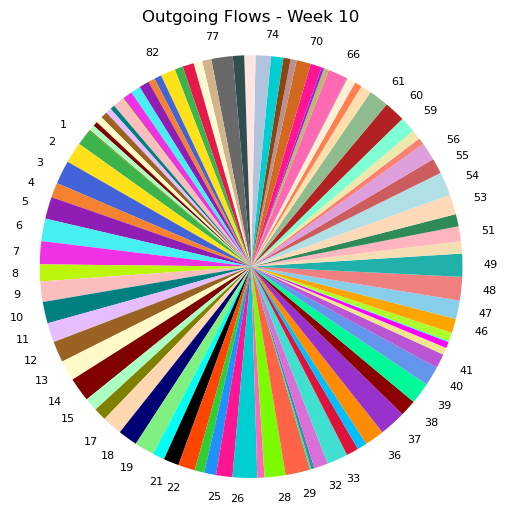


--- Incoming and Outgoing Flow Counts for Week 12 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week12_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week12_incoming.png


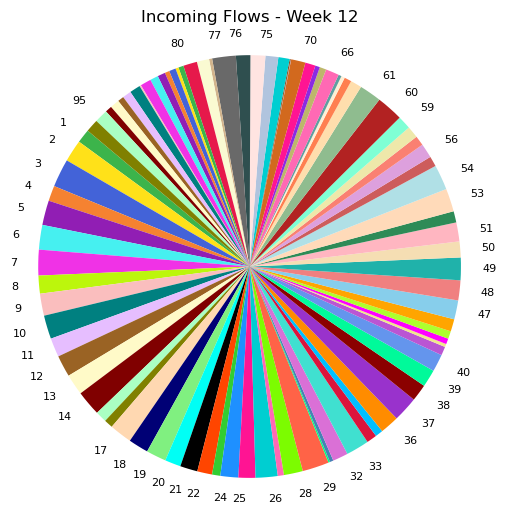

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week12_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week12_outgoing.png


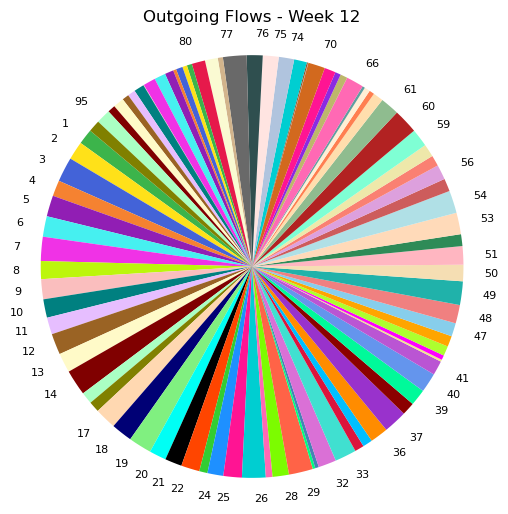


--- Incoming and Outgoing Flow Counts for Week 14 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week14_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week14_incoming.png


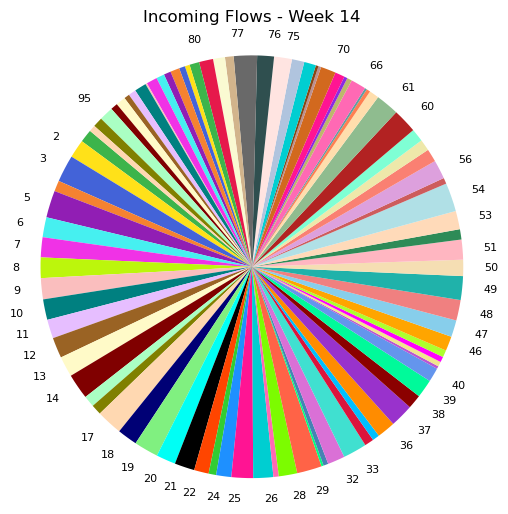

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week14_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week14_outgoing.png


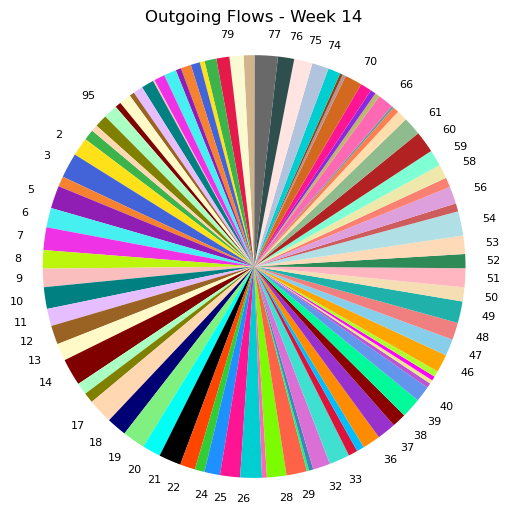


--- Incoming and Outgoing Flow Counts for Week 23 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_incoming.png


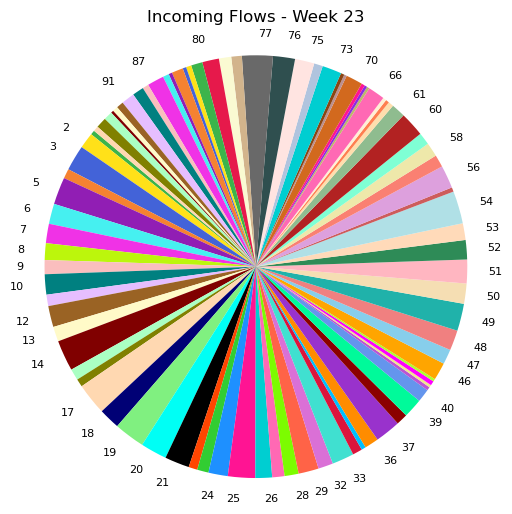

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_outgoing.png


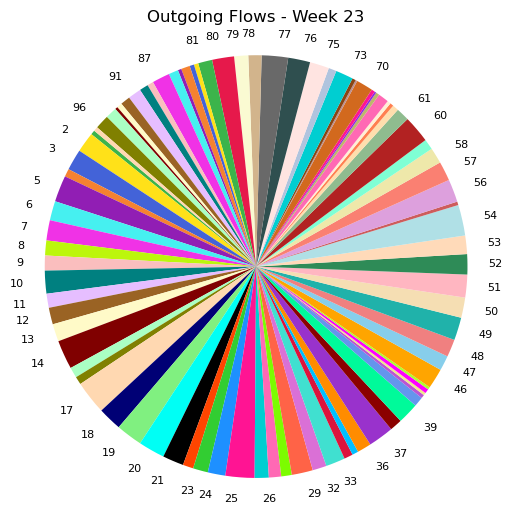


--- Incoming and Outgoing Flow Counts for Week All ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_weekAll_incoming.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_weekAll_incoming.png


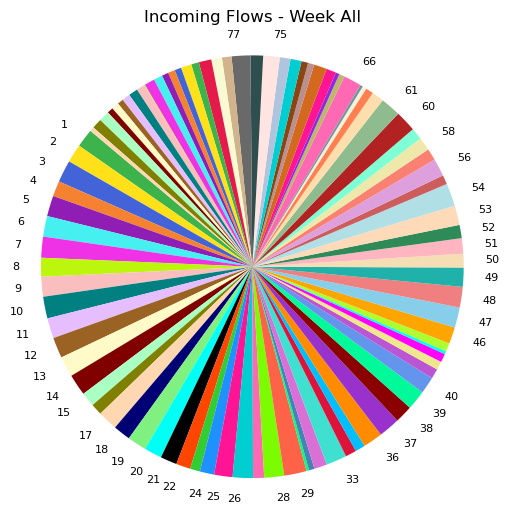

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_weekAll_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_weekAll_outgoing.png


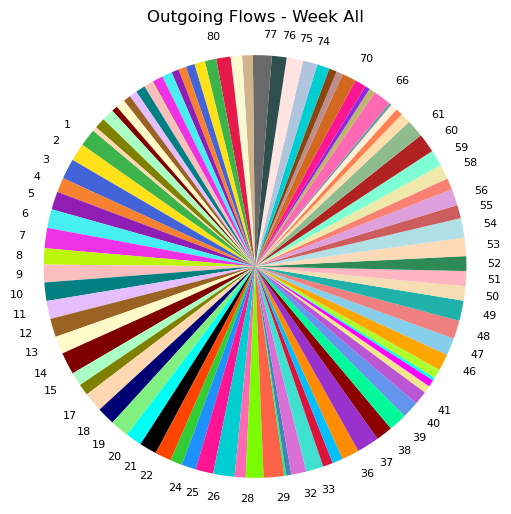

In [73]:
# Pie Flow Chart

for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_sankey_and_pies(
        arena_data,
        week_number,
        eps_dir=eps_dir,
        mouse_name=mouse_name
    )

create_sankey_and_pies(all_data, "All", eps_dir=eps_dir, mouse_name=mouse_name)

In [75]:
# Sankeys Grouped

for week in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_grouped_sankey_plot(
        arena_data,
        week,
        save_path=eps_dir,
        mouse_name=mouse_name
    )

create_grouped_sankey_plot(
    all_data,
    "All",
    save_path=eps_dir,
    mouse_name=mouse_name
)

SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week8.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week8.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week10.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week10.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week12.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week12.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week14.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week14.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week23.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week23.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_weekAll.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_weekAll.png


--- Group Flow Counts for Week 8 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week8_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week8_incoming_grouped.png


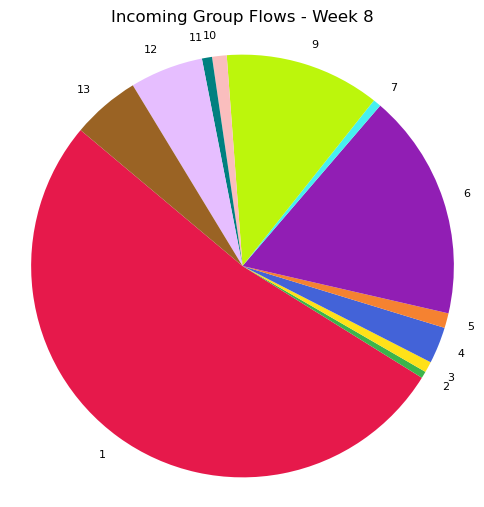

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week8_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week8_outgoing_grouped.png


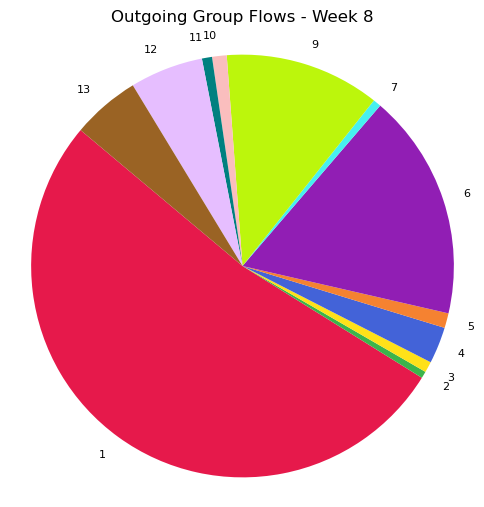

--- Group Flow Counts for Week 10 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week10_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week10_incoming_grouped.png


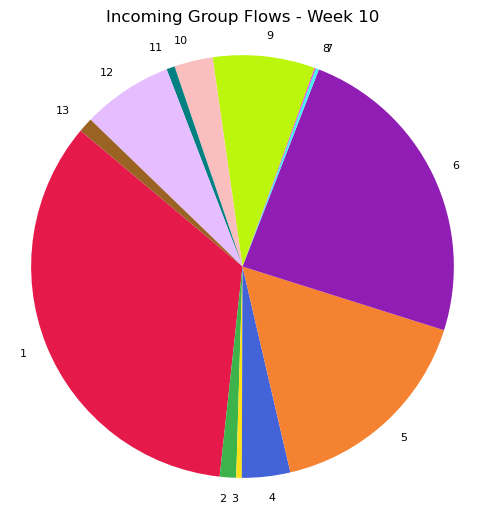

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week10_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week10_outgoing_grouped.png


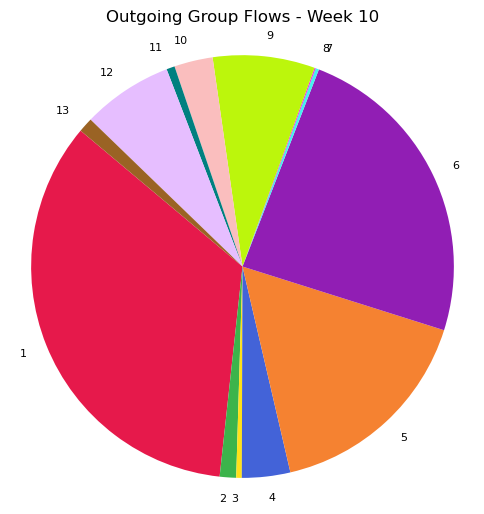

--- Group Flow Counts for Week 12 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week12_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week12_incoming_grouped.png


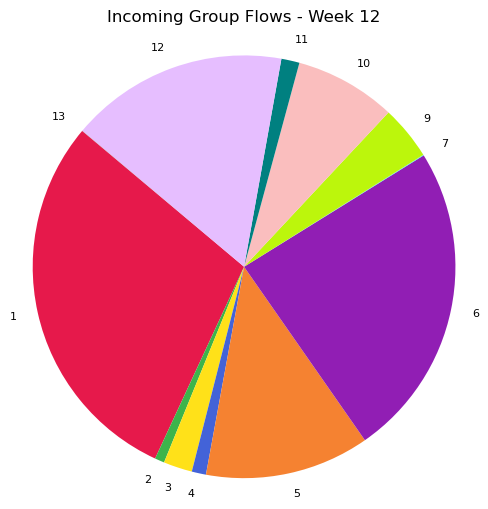

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week12_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week12_outgoing_grouped.png


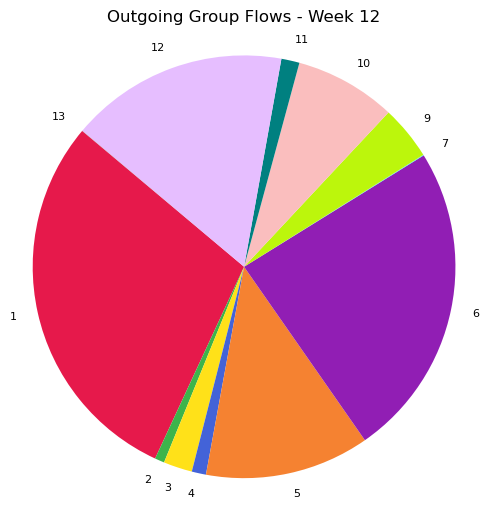

--- Group Flow Counts for Week 14 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week14_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week14_incoming_grouped.png


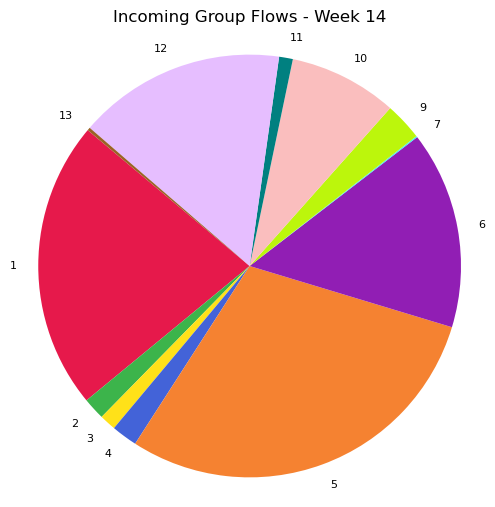

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week14_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week14_outgoing_grouped.png


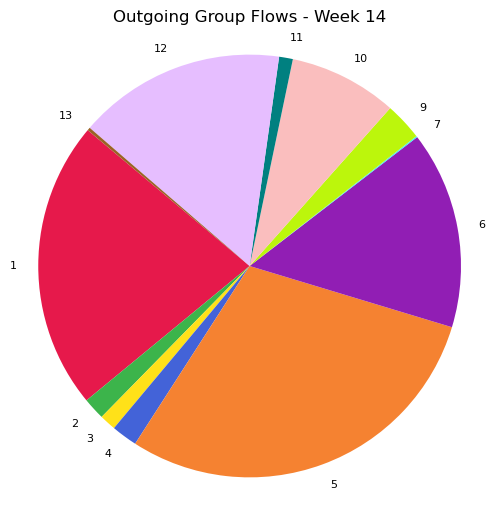

--- Group Flow Counts for Week 23 ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_incoming_grouped.png


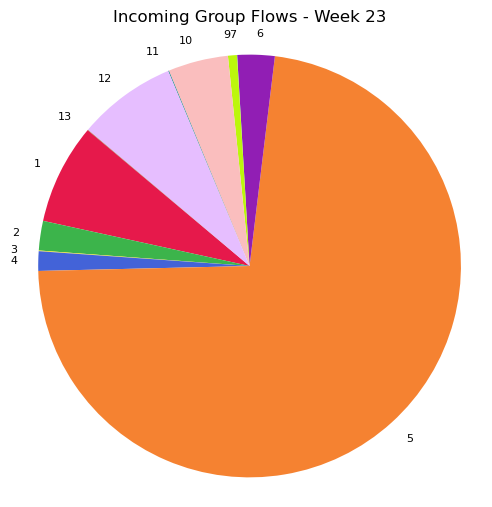

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_outgoing_grouped.png


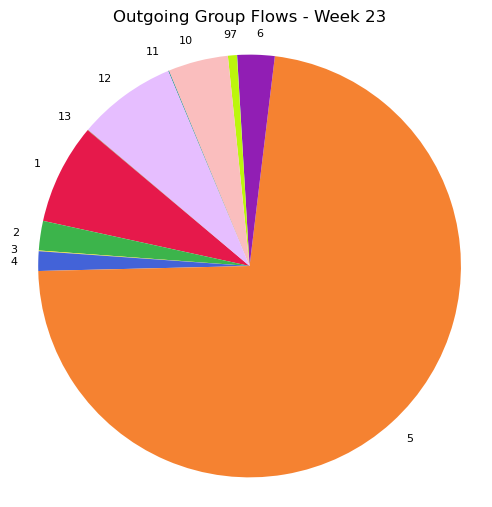

--- Group Flow Counts for Week All ---
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_weekAll_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_weekAll_incoming_grouped.png


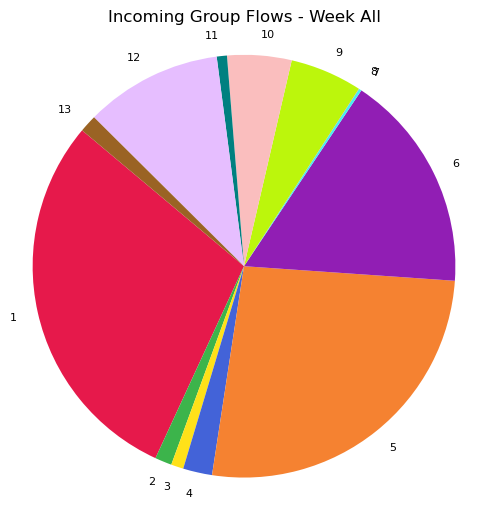

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_weekAll_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_weekAll_outgoing_grouped.png


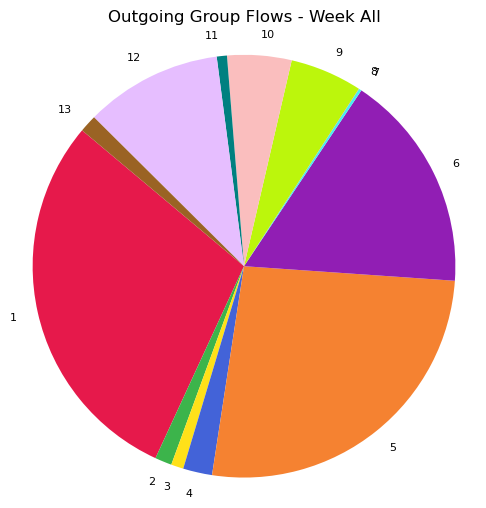

In [76]:
# Pie Flow Chart Grouped 

for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_group_pie_flows(
        arena_data,
        week_number,
        eps_dir=eps_dir,
        mouse_name=mouse_name
    )

create_group_pie_flows(all_data, "All", eps_dir, mouse_name)